# The Augmented Synthetic Control Method with Covariates
### Ben-Michael, Feller and Rothstein

This notebook reproduces the covariate-augmented fit of the Kansas
example from the 2021 paper "The Augmented Synthetic Control Method" by Eli
Ben-Michael, Avi Feller and Jesse Rothstein, *Journal of the American
Statistical Association* 116(536):1789-1803, following the "Augmenting with
covariates" section of the R
[`augsynth`](https://github.com/ebenmichael/augsynth) package vignette
`singlesynth-vignette`:

```r
covsyn <- augsynth(lngdpcapita ~ treated | lngdpcapita + log(revstatecapita) +
                     log(revlocalcapita) + log(avgwklywagecapita) +
                     estabscapita + emplvlcapita,
                   fips, year_qtr, kansas, progfunc = "ridge", scm = T)
```

The vignette does not print any summary numbers for this fit, so - unlike
[kansas.ipynb](kansas.ipynb), which matches the published R outputs of the
no-covariate fit to within $10^{-3}$ - there are no published outputs to
compare against here; the comparison table below instead contrasts the
covariate fit with the (R-validated) no-covariate fit from that notebook.
Both the direct-balance fit and its `residualize = TRUE` variant from the
vignette are reproduced. The study data is contained in the file
`../../data/kansas.csv` (converted from the R `augsynth` package
`data/kansas.rda`).

In [1]:
import pandas as pd
import numpy as np

from pysyncon import Dataprep, AugSynth

The study data is prepared using a `Dataprep` object that describes all
the details needed to define the synthetic control study. This works similarly
to the `dataprep` method in the `R` package `synth`.

As in the R `augsynth` package, the covariates are time-invariant: each is
averaged over the pre-intervention period (all quarters before the treatment
time 2012.25), dropping missing values (the revenue variables are missing in
the early quarters). The log transformations are applied to the quarterly
values before averaging, exactly as in the R formula. Note that
`time_optimize_ssr` must contain all of the pre-treatment time periods.

(For an explanation of each of the `Dataprep` arguments, see the package
[documentation](https://sdfordham.github.io/pysyncon/dataprep.html#pysyncon.Dataprep)).

In [2]:
df = pd.read_csv("../../data/kansas.csv")
df["log_revstatecapita"] = np.log(df["revstatecapita"])
df["log_revlocalcapita"] = np.log(df["revlocalcapita"])
df["log_avgwklywagecapita"] = np.log(df["avgwklywagecapita"])

fips = sorted(df.fips.unique())
pre = sorted(df.loc[df.year_qtr < 2012.25, "year_qtr"].unique())

dataprep = Dataprep(
    foo=df,
    predictors=[
        "lngdpcapita",
        "log_revstatecapita",
        "log_revlocalcapita",
        "log_avgwklywagecapita",
        "estabscapita",
        "emplvlcapita",
    ],
    predictors_op="mean",
    time_predictors_prior=pre,
    dependent="lngdpcapita",
    unit_variable="fips",
    time_variable="year_qtr",
    treatment_identifier=20,
    controls_identifier=[f for f in fips if f != 20],
    time_optimize_ssr=pre,
)

print(dataprep)

Dataprep
Treated unit: 20
Dependent variable: lngdpcapita
Control units: 1.0, 2.0, 4.0, 5.0, 6.0, 8.0, 9.0, 10.0, 12.0, 13.0, 15.0, 16.0, 17.0, 18.0, 19.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 53.0, 54.0, 55.0, 56.0
Time range in data: 1990.0 - 2016.0
Time range for loss minimization: [1990.0, 1990.25, 1990.5, 1990.75, 1991.0, 1991.25, 1991.5, 1991.75, 1992.0, 1992.25, 1992.5, 1992.75, 1993.0, 1993.25, 1993.5, 1993.75, 1994.0, 1994.25, 1994.5, 1994.75, 1995.0, 1995.25, 1995.5, 1995.75, 1996.0, 1996.25, 1996.5, 1996.75, 1997.0, 1997.25, 1997.5, 1997.75, 1998.0, 1998.25, 1998.5, 1998.75, 1999.0, 1999.25, 1999.5, 1999.75, 2000.0, 2000.25, 2000.5, 2000.75, 2001.0, 2001.25, 2001.5, 2001.75, 2002.0, 2002.25, 2002.5, 2002.75, 2003.0, 2003.25, 2003.5, 2003.75, 2004.0, 2004.25, 2004.5, 2004.75, 2005.0, 2005.25, 2005.5, 2005.75, 2006.0, 2006.25, 2006.5, 2

We supply the `Dataprep` object to an `AugSynth` object. The augmented
weights are $w = w_{\text{scm}} + w_{\text{aug}}$ where $w_{\text{scm}}$ are
the standard synthetic control weights and $w_{\text{aug}}$ is an augmentation
obtained by ridge regression of the imbalance of the synthetic control fit on
the pre-treatment outcomes and covariates; the ridge parameter $\lambda$
controls the degree of extrapolation. The weights may be negative and larger
than 1.

In [3]:
augsynth = AugSynth()
augsynth.fit(dataprep)

The following table compares the covariate fit with the no-covariate
fit of [kansas.ipynb](kansas.ipynb) (which reproduces the published R
vignette outputs, `progfunc="Ridge"`, `scm=T`, `lambda` chosen by
cross-validation). Including the covariates improves the pre-treatment fit
further (L2 imbalance 0.0456 against 0.0615) and moves the ATT estimate to
$-0.0641$:

In [4]:
# Post-treatment ATT via the built-in method (weights-only
# counterfactual, as in the R package's `predict` for progfunc="Ridge")
att = augsynth.att(time_period=augsynth.post_periods)["att"]

# the L2 imbalance diagnostics are stored as fitted attributes (computed on
# the raw pre-treatment outcome matrices, as in the R package)
l2 = augsynth.l2_imbalance
pct_improv = 100 * (1 - augsynth.scaled_l2_imbalance)
n_donors = (np.abs(augsynth.W) > 1 / (1000 * len(augsynth.W))).sum()

pd.DataFrame(
    {
        # the no-covariate column is computed in kansas.ipynb (R-validated)
        "covariates": [att, l2, pct_improv, augsynth.avg_bias, n_donors],
        "no covariates": [-0.040063, 0.061515, 84.7, 0.010628, 49],
    },
    index=[
        "Average ATT estimate",
        "L2 imbalance",
        "% improvement over uniform weights",
        "Avg Estimated Bias",
        "Donor units used",
    ],
).round(4)

,covariates,no covariates
Average ATT estimate,-0.0641,-0.0401
L2 imbalance,0.0456,0.0615
% improvement over uniform weights,88.6468,84.7000
Avg Estimated Bias,0.0304,0.0106
Donor units used,49.0000,49.0000


Because the covariates are concatenated with the pre-treatment outcomes
in the design matrix, the SCM step balances them jointly with the outcomes.
The table below shows the treated unit's covariate values and the weighted
control covariate values (centered at the control mean and scaled by the
ratio `sdx`/`sdz`, as in the R package). The ridge augmentation removes most
of the covariate imbalance left by the SCM weights (total absolute imbalance
0.1011 against 0.0036):

In [5]:
Z0, Z1 = dataprep.make_covariate_mats()
Z0_c = Z0.subtract(Z0.mean(axis=1), axis=0)
Z1_c = Z1.subtract(Z0.mean(axis=1), axis=0)
sdz = Z0_c.std(axis=1)
X0, X1 = dataprep.make_outcome_mats(time_period=augsynth.pre_periods)
sdx = X0.subtract(X0.mean(axis=1), axis=0).to_numpy().std(ddof=1)

pd.DataFrame(
    {
        "treated (scaled)": Z1_c.divide(sdz, axis=0) * sdx,
        "SCM controls (scaled)": (Z0_c * augsynth.synw).sum(axis=1).divide(
            sdz, axis=0
        )
        * sdx,
        "augmented controls (scaled)": (Z0_c * augsynth.W).sum(axis=1).divide(
            sdz, axis=0
        )
        * sdx,
    }
).round(4)

,treated (scaled),SCM controls (scaled),augmented controls (scaled)
lngdpcapita,-0.0393,-0.0386,-0.0393
log_revstatecapita,-0.0441,-0.0326,-0.0441
log_revlocalcapita,0.0870,0.0607,0.0872
log_avgwklywagecapita,-0.1053,-0.1106,-0.1050
estabscapita,0.0263,0.0375,0.0257
emplvlcapita,0.1327,0.0866,0.1302


The donor units with the largest weights (only weights above 0.01 in
absolute value are shown) are:

In [6]:
augsynth.weights(round=4, threshold=0.01).sort_values(ascending=False)

45.0    0.3562
31.0    0.1787
29.0    0.1704
49.0    0.1687
53.0    0.1687
17.0    0.1426
40.0    0.1351
39.0    0.1304
48.0    0.1287
18.0    0.0944
50.0    0.0837
38.0    0.0766
21.0    0.0537
36.0    0.0452
12.0    0.0385
37.0    0.0364
23.0    0.0361
56.0    0.0319
55.0    0.0286
15.0    0.0273
8.0     0.0159
46.0    0.0156
2.0     0.0155
6.0     0.0148
19.0    0.0147
Name: weights, dtype: float64

The `path_plot` method shows the path of the treated unit and the
synthetic control over time.

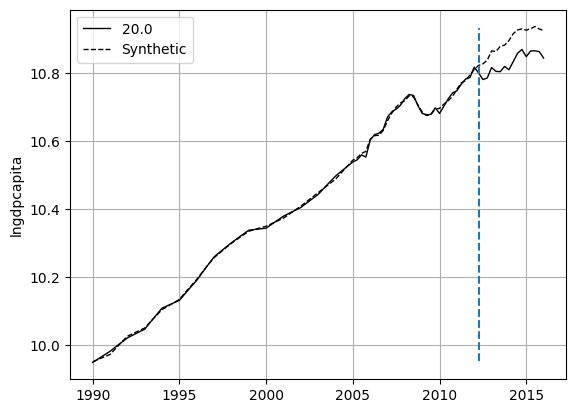

(<Figure size 640x480 with 1 Axes>, <Axes: ylabel='lngdpcapita'>)

In [7]:
augsynth.path_plot(
    time_period=sorted(df.year_qtr.unique()), treatment_time=2012.25
)

The `gaps_plot` method shows the gaps (the difference between the
treated unit and the synthetic control) over time.

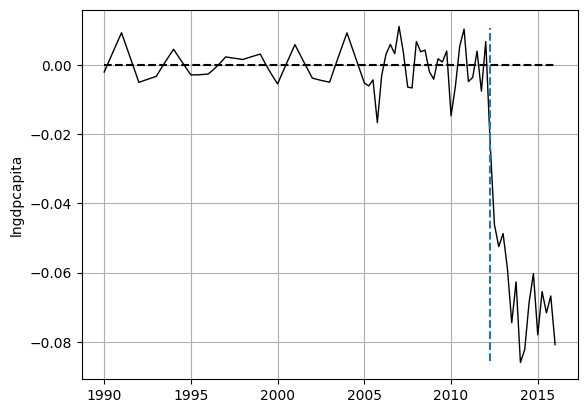

In [8]:
augsynth.gaps_plot(
    time_period=sorted(df.year_qtr.unique()), treatment_time=2012.25
)

Compute the average treatment effect on the treated unit (ATT) over the
post-treatment time period. This method returns a standard error also.

In [9]:
augsynth.att(time_period=augsynth.post_periods)

{'att': -0.06406206422952665, 'se': 0.004069439361018645}

When `lambda_` is not supplied, it is obtained by cross-validation over a
grid of 21 log-spaced values. The `cv_result` attribute contains the
cross-validation results; `cv_result.plot()` plots the mean cross-validation
error against $\lambda$ with standard error bars.

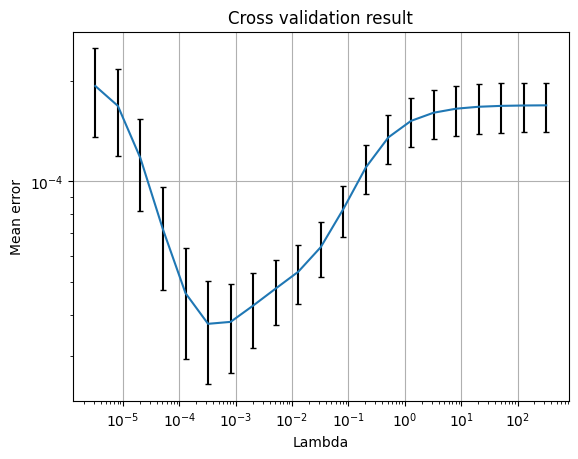

min-error lambda: 0.000323047916877996
1-SE-selected lambda: 0.005119964442986796


In [10]:
augsynth.cv_result.plot()
print(
    "min-error lambda:",
    augsynth.cv_result.lambdas[augsynth.cv_result.errors_mean.argmin()],
)
print("1-SE-selected lambda:", augsynth.cv_result.best_lambda(min_1se=True))

The vignette also fits a variant of the covariate fit with
`residualize = TRUE`: instead of balancing the covariates directly, the
pre-treatment outcomes are regressed on the covariates with OLS (using the
control units) and the ridge fit is performed on the covariate residuals; the
covariates are then re-added to the weights exactly, so that the final
weights balance the covariates exactly. The vignette fits this variant with
`lambda = asyn$lambda`, the cross-validated ridge parameter of the
no-covariate fit (see [kansas.ipynb](kansas.ipynb)).

In [11]:
augsynth_res = AugSynth()
# asyn$lambda - the cross-validated lambda of the no-covariate fit in
# kansas.ipynb (1-standard-error rule)
augsynth_res.fit(dataprep, lambda_=0.07866222813499749, residualize=True)

The following table compares the residualized fit with the
direct-balance fit above:

In [12]:
att_res = augsynth_res.att(time_period=augsynth_res.post_periods)["att"]

l2_res = augsynth_res.l2_imbalance
pct_improv_res = 100 * (1 - augsynth_res.scaled_l2_imbalance)
n_donors_res = (np.abs(augsynth_res.W) > 1 / (1000 * len(augsynth_res.W))).sum()

pd.DataFrame(
    {
        "residualize=True": [
            att_res,
            l2_res,
            pct_improv_res,
            augsynth_res.avg_bias,
            n_donors_res,
        ],
        "balance directly": [att, l2, pct_improv, augsynth.avg_bias, n_donors],
    },
    index=[
        "Average ATT estimate",
        "L2 imbalance",
        "% improvement over uniform weights",
        "Avg Estimated Bias",
        "Donor units used",
    ],
).round(4)

,residualize=True,balance directly
Average ATT estimate,-0.0548,-0.0641
L2 imbalance,0.0669,0.0456
% improvement over uniform weights,83.3544,88.6468
Avg Estimated Bias,0.0064,0.0304
Donor units used,49.0000,49.0000


In [13]:
# the covariate re-add balances the covariates exactly (up to
# numerical precision), the hallmark of residualize=TRUE
print(
    "L2 covariate imbalance (residualize=True):",
    augsynth_res.covariate_l2_imbalance,
)

L2 covariate imbalance (residualize=True): 2.5448458429845787e-16


The average estimated bias is computed from the `ridge_mhat` outcome
model (a ridge regression of the post-treatment control outcomes on the design
matrix), exactly as in the R `augsynth` package: the estimated bias in each
post-treatment period is `bias_est = mhat[treated] - synw @ mhat[controls]`
(using the synthetic control weights), stored in `augsynth.bias_est`, with
`augsynth.avg_bias` the average over the post-treatment periods. In the
direct-balance fit the covariates enter the outcome model as well: `beta` is
estimated on the 95-row design matrix (89 pre-treatment outcome rows plus 6
covariate rows). In the `residualize = TRUE` fit the outcome model has an
OLS component from the covariates plus a ridge component on the residualized
outcomes, and `augsynth_res.no_cov_weights` stores the weights before the
covariate re-add.

The pre-treatment fit diagnostics are stored as fitted attributes:
`l2_imbalance`, `unif_l2_imbalance` and `scaled_l2_imbalance` (with
`1 - scaled_l2_imbalance` the percentage improvement over uniform weights),
plus `covariate_l2_imbalance` and `scaled_covariate_l2_imbalance` when
covariates are used.

`PlaceboTest` works with `AugSynth` but is slow on this dataset (49 placebo
fits, each with its own cross-validation).